In [34]:
# import library
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix

In [35]:
#load data
df = pd.read_csv("C:/Users/ASUS/Downloads/archive (2)/dataset.csv")

In [36]:
df.head()

,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,...,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,...,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic
1,1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,...,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic
2,2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,...,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic
3,3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,...,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic
4,4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,...,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic


# EDA

In [76]:
#drop kolom tak berguna
df.drop(columns=["track_id", "track_name", "artist_name", "album_name",
                 "label", "country"],
         inplace=True, errors='ignore')

df['duration_minutes'] = df['duration_ms'] / 60000

df.head()

,Unnamed: 0,artists,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre,duration_minutes
0,0,Gen Hoshino,73,230666,False,0.676,0.4610,1,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic,3.844433
1,1,Ben Woodward,55,149610,False,0.420,0.1660,1,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic,2.493500
2,2,Ingrid Michaelson;ZAYN,57,210826,False,0.438,0.3590,0,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic,3.513767
3,3,Kina Grannis,71,201933,False,0.266,0.0596,0,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic,3.365550
4,4,Chord Overstreet,82,198853,False,0.618,0.4430,2,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic,3.314217


Jumlah genre unik: 114
track_genre
acoustic       1000
afrobeat       1000
alt-rock       1000
alternative    1000
ambient        1000
               ... 
techno         1000
trance         1000
trip-hop       1000
turkish        1000
world-music    1000
Name: count, Length: 114, dtype: int64


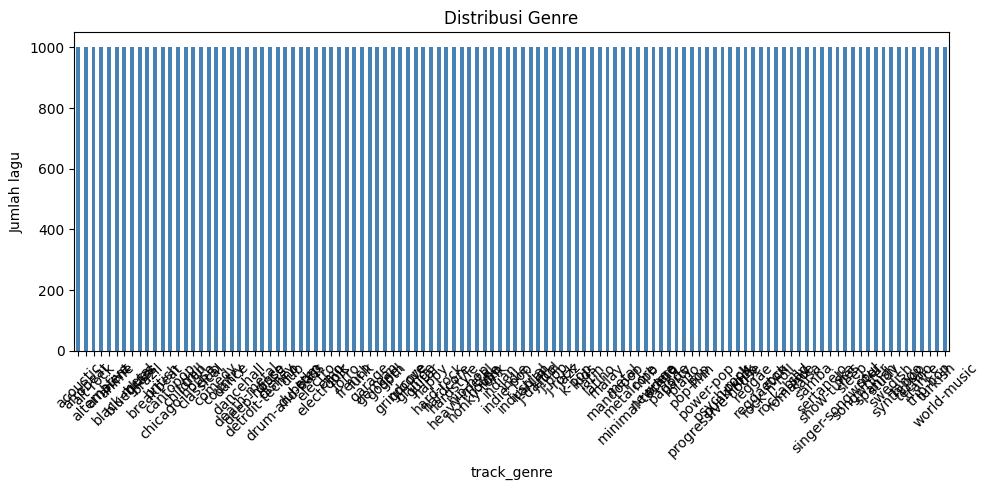

In [77]:
GENRE_COL = 'track_genre'

print("Jumlah genre unik:", df[GENRE_COL].nunique())
print(df[GENRE_COL].value_counts())

plt.figure(figsize=(10, 5))
df[GENRE_COL].value_counts().plot(kind='bar', color='steelblue')
plt.title('Distribusi Genre')
plt.ylabel('Jumlah lagu')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [78]:
#cek missing value
print(df.isnull().sum().sort_values(ascending=False).head(15))

artists             1
Unnamed: 0          0
popularity          0
duration_ms         0
explicit            0
danceability        0
energy              0
key                 0
loudness            0
mode                0
speechiness         0
acousticness        0
instrumentalness    0
liveness            0
valence             0
dtype: int64


In [79]:
numeric_features = [
    'danceability', 'energy', 'loudness', 'tempo',
    'instrumentalness', 'acousticness', 'speechiness',
    'liveness', 'valence',
    'upbeat_score', 'duration_minutes'
]

categorical_features = [
    'popularity_category', 'loudness_category',
    'key_name', 'mode_name',
    'is_explicit_bool', 'is_weekend_release'
]

# Cek kolom yang hilang
missing = [c for c in numeric_features + categorical_features if c not in df.columns]
print("Kolom yang hilang:", missing)

# Pakai hanya yang ada
numeric_features     = [c for c in numeric_features     if c in df.columns]
categorical_features = [c for c in categorical_features if c in df.columns]

print("\nNumerik final    :", numeric_features)
print("Kategorikal final:", categorical_features)

df[numeric_features].describe()

Kolom yang hilang: ['upbeat_score', 'popularity_category', 'loudness_category', 'key_name', 'mode_name', 'is_explicit_bool', 'is_weekend_release']

Numerik final    : ['danceability', 'energy', 'loudness', 'tempo', 'instrumentalness', 'acousticness', 'speechiness', 'liveness', 'valence', 'duration_minutes']
Kategorikal final: []


,danceability,energy,loudness,tempo,instrumentalness,acousticness,speechiness,liveness,valence,duration_minutes
count,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000
mean,0.566800,0.641383,-8.258960,122.147837,0.156050,0.314910,0.084652,0.213553,0.474068,3.800486
std,0.173542,0.251529,5.029337,29.978197,0.309555,0.332523,0.105732,0.190378,0.259261,1.788295
min,0.000000,0.000000,-49.531000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.456000,0.472000,-10.013000,99.218750,0.000000,0.016900,0.035900,0.098000,0.260000,2.901100
50%,0.580000,0.685000,-7.004000,122.017000,0.000042,0.169000,0.048900,0.132000,0.464000,3.548433
75%,0.695000,0.854000,-5.003000,140.071000,0.049000,0.598000,0.084500,0.273000,0.683000,4.358433
max,0.985000,1.000000,4.532000,243.372000,1.000000,0.996000,0.965000,1.000000,0.995000,87.288250


# Preprocessing

In [80]:
#split fitur dan target
X = df[numeric_features + categorical_features]
y = df[GENRE_COL]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

X_train.shape, X_test.shape, y_train.shape, y_test.shape

((91200, 10), (22800, 10), (91200,), (22800,))

In [81]:
#preprocessing
numeric_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', MinMaxScaler())
])
categorical_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder())
])

preprocessor = ColumnTransformer([
    ('num', numeric_pipeline, numeric_features),
    ('cat', categorical_pipeline, categorical_features)
])

In [82]:
#Pipeline utama
pipeline = Pipeline([
    ("prep", preprocessor),
    ("algo", KNeighborsClassifier())
])

In [87]:
pipeline.fit(X_train, y_train)

,steps,"[('prep', ...), ('algo', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [88]:
pipeline.score(X_test, y_test)

0.15482456140350878

In [84]:
#Grid Search CV
parameter = {
     "algo__n_neighbors": [5, 15, 25, 35, 51, 75, 101, 151],
    "algo__weights": ["uniform", "distance"],
    "algo__p": [1, 2]
}

model = GridSearchCV(
    pipeline, parameter,
    cv=3,
    n_jobs=-1, verbose=1, scoring='accuracy'
)

In [85]:
categorical_features = [
    'popularity_category', 'loudness_category', 'is_explicit_bool'
]

In [86]:
model.fit(X_train, y_train)
print("CV:", model.best_score_, "| Test:", model.score(X_test, y_test))
model.fit(X_train, y_train)

print("\nBest Params  :", model.best_params_)
print("Best CV Score:", model.best_score_)

Fitting 3 folds for each of 32 candidates, totalling 96 fits


C:\Users\ASUS\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\_response.py:203: UserWarning: The number of unique classes is greater than 50% of the number of samples.
  target_type = type_of_target(classes)


CV: 0.19587719298245612 | Test: 0.19276315789473683
Fitting 3 folds for each of 32 candidates, totalling 96 fits

Best Params  : {'algo__n_neighbors': 101, 'algo__p': 1, 'algo__weights': 'distance'}
Best CV Score: 0.19587719298245612
